In [31]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
from sklearn.model_selection import train_test_split
df = pd.read_csv(r'C:/Users/p489000/OneDrive - Szkoła Główna Gospodarstwa Wiejskiego/Pulpit/DeepLearning2025/Wykład3/Iris3.csv',sep=';')
# retrieve array
print(df.shape)


(150, 3)


In [33]:
df

,x1,x2,y
0,0.2,3.5,Iris-setosa
1,0.2,3.0,Iris-setosa
2,0.2,3.2,Iris-setosa
3,0.2,3.1,Iris-setosa
4,0.2,3.6,Iris-setosa
...,...,...,...
145,2.3,3.0,Iris-virginica
146,1.9,2.5,Iris-virginica
147,2.0,3.0,Iris-virginica
148,2.3,3.4,Iris-virginica


In [34]:
df['y'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [35]:
y1=pd.Categorical(df['y']).rename_categories({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
y1

[0, 0, 0, 0, 0, ..., 2, 2, 2, 2, 2]
Length: 150
Categories (3, int64): [0, 1, 2]

In [36]:
df1=df.drop(['y'],axis=1)


Tworzymy wykres

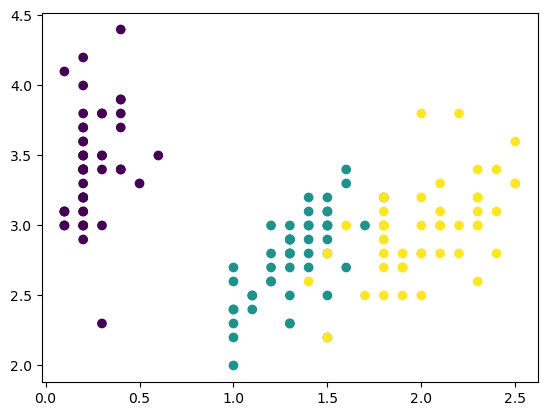

In [37]:
import matplotlib.pyplot as plt
plt.scatter(x=df1["x1"], y=df1['x2'], c=y1)
plt.show()

In [38]:
df1.shape

(150, 2)

In [39]:
y1.shape

(150,)

In [40]:
X=torch.from_numpy(df1.values).type(torch.float)
y=torch.tensor(y1).type(torch.LongTensor)

In [41]:
X[:5], y[:5]

(tensor([[0.2000, 3.5000],
         [0.2000, 3.0000],
         [0.2000, 3.2000],
         [0.2000, 3.1000],
         [0.2000, 3.6000]]),
 tensor([0, 0, 0, 0, 0]))

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
len(X_train), len(X_test), len(y_train), len(y_test)

(120, 30, 120, 30)

Budowa modelu

In [44]:
NUM_Features=2
NUM_CLASSES=3

In [45]:
import torch
from torch import nn

In [46]:
import torch.nn.functional as F

class IrisModel1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=2)
        self.layer_2 = nn.Linear(in_features=2, out_features=3) # extra layer
        self.relu = nn.ReLU() # <- dodanie ReLU jako funkcji aktywacji

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return x
'''
        # inna możliwość
        return self.layer_3(self.relu((self.layer_2(self.relu(self.layer_1(x))))))
'''

Iris_model1 = IrisModel1()
print(Iris_model1)

def count_parameters(Iris_model1):
    return sum(p.numel() for p in Iris_model1.parameters() if p.requires_grad)
print(f'The model has {count_parameters(Iris_model1):,} trainable parameters')

IrisModel1(
  (layer_1): Linear(in_features=2, out_features=2, bias=True)
  (layer_2): Linear(in_features=2, out_features=3, bias=True)
  (relu): ReLU()
)
The model has 15 trainable parameters


In [47]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(Iris_model1.parameters(), lr=0.1)

In [48]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [49]:
# Wybierz ziarno
torch.manual_seed(42)

# Ustal liczbę epok
epochs = 100

for epoch in range(epochs):
    ### Uczenie
    Iris_model1.train()

    # 1. Propagacja w przód
    y_logits = Iris_model1(X_train) # wyrzuca logity
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # przejście z logitów ->  prawdopodobieństwa -> przewidywane etykiety
    # print(y_logits)
    # 2. Strata i dokładność
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Wyzarowanie gradientów
    optimizer.zero_grad()

    # 4. Propadacja wsteczna
    loss.backward()

    # 5. Optymalizator
    optimizer.step()

    ### Testowanie
    Iris_model1.eval()
    with torch.inference_mode():
      # 1. Propagacja w przód
      test_logits = Iris_model1(X_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Strata i dokładność
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Wydruk
    if epoch % 10 == 0:
        print(f"Epoka: {epoch} | Strata: {loss:.5f}, Acc: {acc:.2f}% | Strata testowa: {test_loss:.5f}, Acc: {test_acc:.2f}%")

Epoka: 0 | Strata: 1.21000, Acc: 32.50% | Strata testowa: 0.99308, Acc: 36.67%
Epoka: 10 | Strata: 0.86199, Acc: 37.50% | Strata testowa: 0.84182, Acc: 40.00%
Epoka: 20 | Strata: 0.74939, Acc: 48.33% | Strata testowa: 0.72668, Acc: 46.67%
Epoka: 30 | Strata: 0.65143, Acc: 65.83% | Strata testowa: 0.62655, Acc: 70.00%
Epoka: 40 | Strata: 0.57597, Acc: 67.50% | Strata testowa: 0.54983, Acc: 70.00%
Epoka: 50 | Strata: 0.51852, Acc: 83.33% | Strata testowa: 0.49149, Acc: 86.67%
Epoka: 60 | Strata: 0.47290, Acc: 90.00% | Strata testowa: 0.44521, Acc: 93.33%
Epoka: 70 | Strata: 0.43477, Acc: 94.17% | Strata testowa: 0.40667, Acc: 96.67%
Epoka: 80 | Strata: 0.40159, Acc: 93.33% | Strata testowa: 0.37338, Acc: 96.67%
Epoka: 90 | Strata: 0.37200, Acc: 94.17% | Strata testowa: 0.34402, Acc: 96.67%


In [50]:
Iris_model1.eval()
with torch.inference_mode():
    y_logits = Iris_model1(X_test)

# Podgląd 10 pierwszych predykcji
y_logits[:10]

tensor([[ 0.0666,  1.8209,  1.0483],
        [ 3.8362,  0.8258, -2.8992],
        [-3.4786,  3.0757,  4.9061],
        [-0.7397,  2.1689,  1.9543],
        [-0.5402,  2.0504,  1.7153],
        [ 3.1172,  0.9255, -2.1873],
        [-0.1329,  1.9394,  1.2872],
        [-2.9591,  3.0945,  4.4332],
        [-1.4670,  2.1425,  2.6164],
        [-0.0373,  1.8171,  1.1429]])

In [51]:
# Zamiana logitów w prawdopodobieństwa
y_pred_probs = torch.softmax(y_logits, dim=1)

# Zamiana prawdopodobieństw na etykiety
y_preds = y_pred_probs.argmax(dim=1)

# Porównanie pierwszych 10 preds i test labels
print(f"Przewidywania: {y_preds[:10]}\nLabels: {y_test[:10]}")
print(f"Dokładność: {accuracy_fn(y_true=y_test, y_pred=y_preds)}%")

Przewidywania: tensor([1, 0, 2, 1, 1, 0, 1, 2, 2, 1])
Labels: tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])
Dokładność: 93.33333333333333%


In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_preds, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



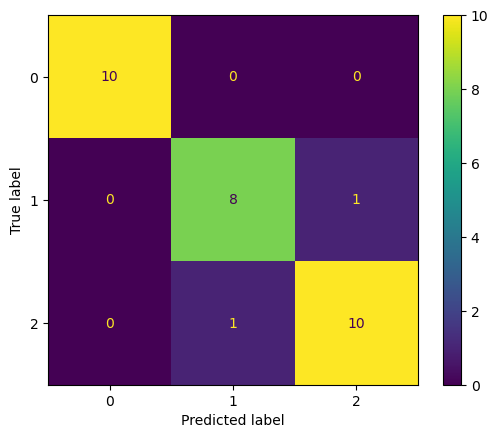

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay


# Create the confusion matrix
cm = confusion_matrix(y_test, y_preds)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [54]:
import requests
from pathlib import Path

# Pobieranie funkcji z zewnętrznego źródła
if Path("helper_functions.py").is_file():
  print("helper_functions.py już istnieje, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("C:/Users/p489000/OneDrive - Szkoła Główna Gospodarstwa Wiejskiego/Pulpit/DeepLearning2025/Wykład3/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py już istnieje, skipping download


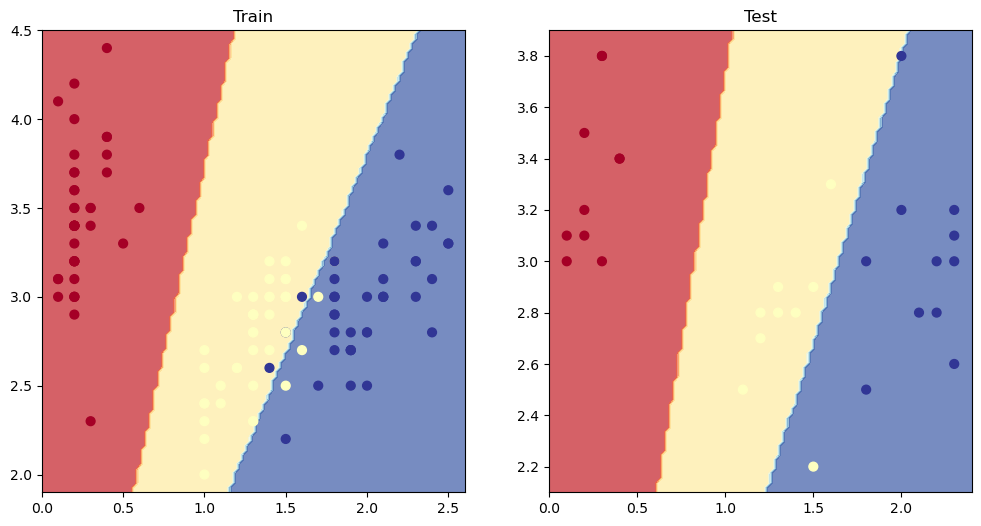

In [55]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Iris_model1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Iris_model1, X_test, y_test)

In [56]:
Iris_model1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 1.6593,  0.1138],
                      [-1.1855,  1.0121]])),
             ('layer_1.bias', tensor([-0.1477,  0.1319])),
             ('layer_2.weight',
              tensor([[-1.0137,  1.1405],
                      [ 0.6648, -0.0375],
                      [ 1.2425, -1.0742]])),
             ('layer_2.bias', tensor([0.4980, 0.4414, 0.0197]))])